#1. Chuẩn bị dữ liệu và Phân tích phân bố

KẾT QUẢ KIỂM TRA TỶ LỆ PHÂN TẦNG (STRATIFIED):
--------------------------------------------------
Tỷ lệ Train/Test: 40/60
 - Tỷ lệ bệnh trong dữ liệu gốc: 61.54%
 - Tỷ lệ bệnh trong tập Train:   61.54%
 - Tỷ lệ bệnh trong tập Test:    61.54%
------------------------------
Tỷ lệ Train/Test: 60/40
 - Tỷ lệ bệnh trong dữ liệu gốc: 61.54%
 - Tỷ lệ bệnh trong tập Train:   61.54%
 - Tỷ lệ bệnh trong tập Test:    61.54%
------------------------------
Tỷ lệ Train/Test: 80/20
 - Tỷ lệ bệnh trong dữ liệu gốc: 61.54%
 - Tỷ lệ bệnh trong tập Train:   61.54%
 - Tỷ lệ bệnh trong tập Test:    61.54%
------------------------------
Tỷ lệ Train/Test: 90/10
 - Tỷ lệ bệnh trong dữ liệu gốc: 61.54%
 - Tỷ lệ bệnh trong tập Train:   61.54%
 - Tỷ lệ bệnh trong tập Test:    61.54%
------------------------------


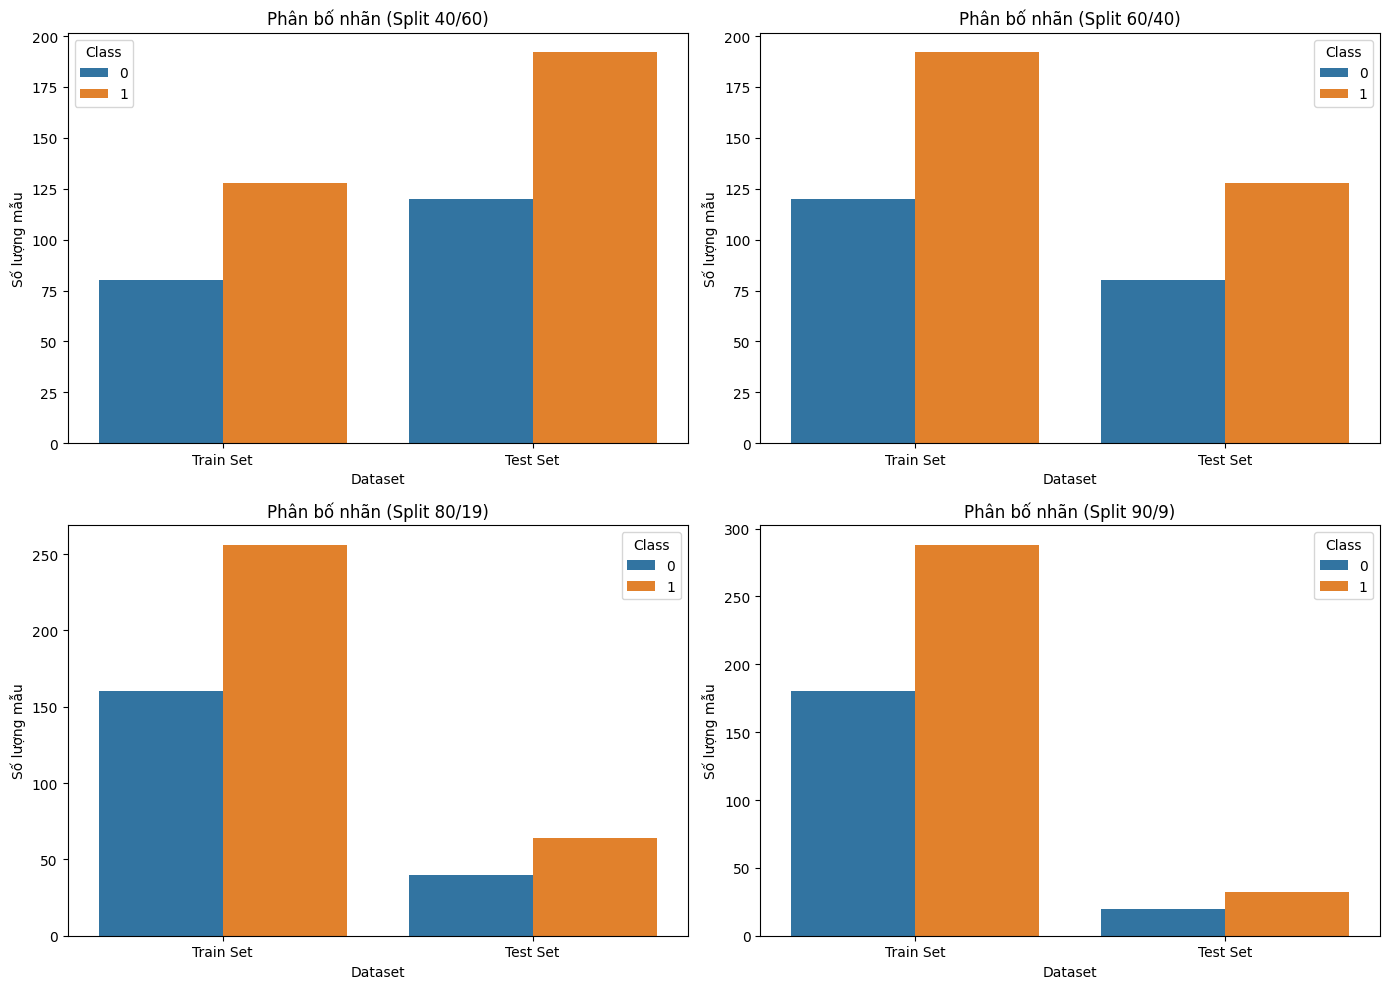

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- BƯỚC A: TẢI VÀ XỬ LÝ DỮ LIỆU ---
# Đọc file csv (Hãy thay tên file của bạn vào đây)
df = pd.read_csv('diabetes_data_upload.csv') # Ví dụ tên file chuẩn

# Chuyển đổi dữ liệu chữ sang số (Encoding) vì máy tính chỉ hiểu số
# Ví dụ: Gender (Male/Female) -> (1/0)
label_encoders = {}
for column in df.columns:
    if df[column].dtype == object:
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

# Tách Features (X) và Label (y)
target_col = 'class' # Tên cột kết quả (bị bệnh hay không)
X = df.drop(target_col, axis=1)
y = df[target_col]

# --- BƯỚC B: CHIA DỮ LIỆU & KIỂM TRA (Mục 2.1) ---
# Các tỷ lệ train cần thử nghiệm theo yêu cầu đề bài
ratios = [0.4, 0.6, 0.8, 0.9]

print("KẾT QUẢ KIỂM TRA TỶ LỆ PHÂN TẦNG (STRATIFIED):")
print("-" * 50)

# Tạo khung để vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, train_size in enumerate(ratios):
    # CÂU LỆNH QUAN TRỌNG NHẤT: train_test_split
    # shuffle=True: Trộn dữ liệu
    # stratify=y: Chia đều tỷ lệ dựa theo nhãn y
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=train_size,
        shuffle=True,
        stratify=y,
        random_state=42
    )

    # Tính toán tỷ lệ Positive (người bệnh) trong từng tập để kiểm tra
    orig_ratio = y.value_counts(normalize=True)[1]
    train_ratio = y_train.value_counts(normalize=True)[1]
    test_ratio = y_test.value_counts(normalize=True)[1]

    print(f"Tỷ lệ Train/Test: {round(train_size*100)}/{round((1-train_size)*100)}")
    print(f" - Tỷ lệ bệnh trong dữ liệu gốc: {orig_ratio:.2%}")
    print(f" - Tỷ lệ bệnh trong tập Train:   {train_ratio:.2%}")
    print(f" - Tỷ lệ bệnh trong tập Test:    {test_ratio:.2%}")
    print("-" * 30)

    # Vẽ biểu đồ phân bố cho từng tỷ lệ (Yêu cầu mục 2.1)
    # Gom dữ liệu lại để vẽ
    plot_data = pd.DataFrame({
        'Dataset': ['Train Set'] * len(y_train) + ['Test Set'] * len(y_test),
        'Class': list(y_train) + list(y_test)
    })

    sns.countplot(data=plot_data, x='Dataset', hue='Class', ax=axes[i])
    axes[i].set_title(f'Phân bố nhãn (Split {int(train_size*100)}/{int((1-train_size)*100)})')
    axes[i].set_ylabel('Số lượng mẫu')

plt.tight_layout()
plt.show()

#2. Xây dựng và Đánh giá Cây quyết định theo tỷ lệ chia

=== BƯỚC 2: HUẤN LUYỆN VÀ ĐÁNH GIÁ CÂY QUYẾT ĐỊNH (ENTROPY) ===


==================== TỶ LỆ TRAIN: 40% - TEST: 60% ====================
Confusion Matrix (Ma trận nhầm lẫn):
[[116   4]
 [ 13 179]]

Classification Report (Báo cáo chi tiết):
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       120
           1       0.98      0.93      0.95       192

    accuracy                           0.95       312
   macro avg       0.94      0.95      0.94       312
weighted avg       0.95      0.95      0.95       312

-> Hình ảnh cây quyết định cho tỷ lệ 40/60:


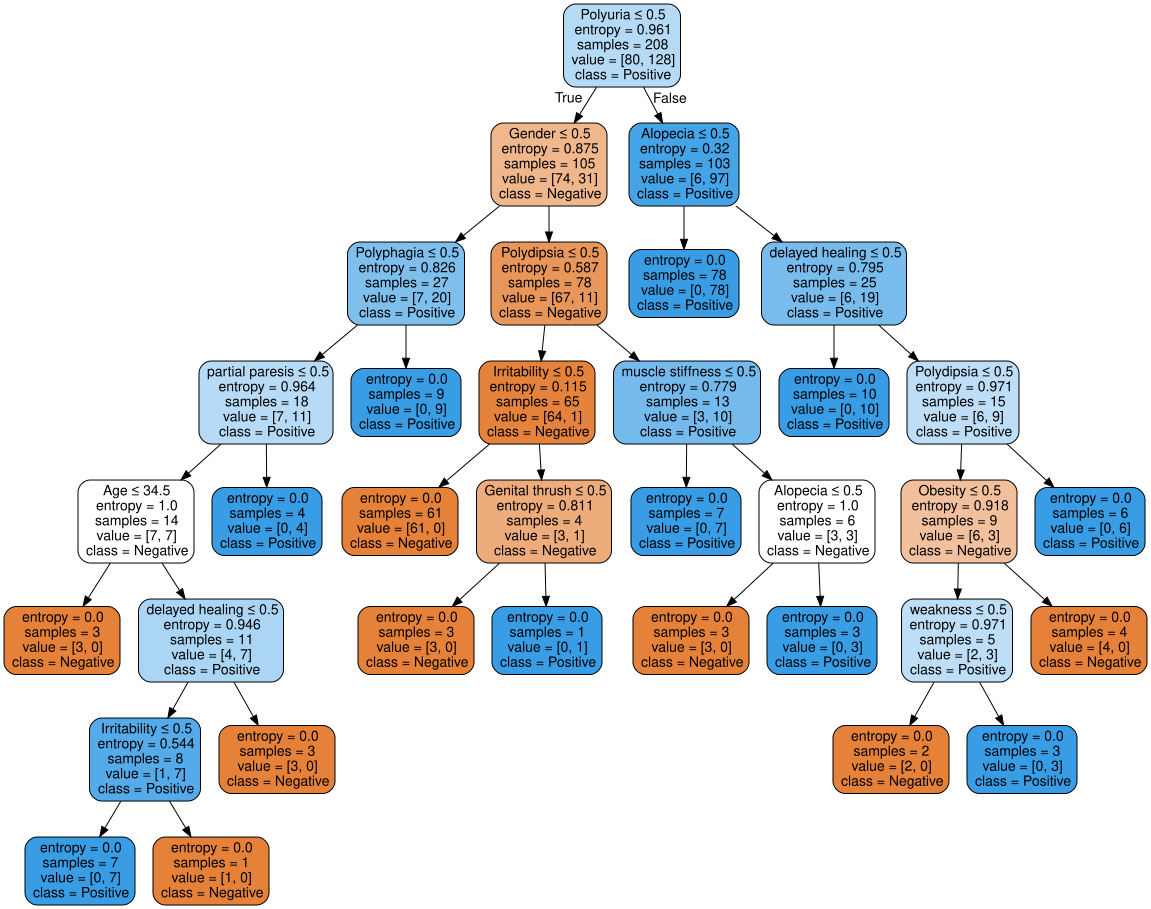



==================== TỶ LỆ TRAIN: 60% - TEST: 40% ====================
Confusion Matrix (Ma trận nhầm lẫn):
[[ 79   1]
 [  5 123]]

Classification Report (Báo cáo chi tiết):
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        80
           1       0.99      0.96      0.98       128

    accuracy                           0.97       208
   macro avg       0.97      0.97      0.97       208
weighted avg       0.97      0.97      0.97       208

-> Hình ảnh cây quyết định cho tỷ lệ 60/40:


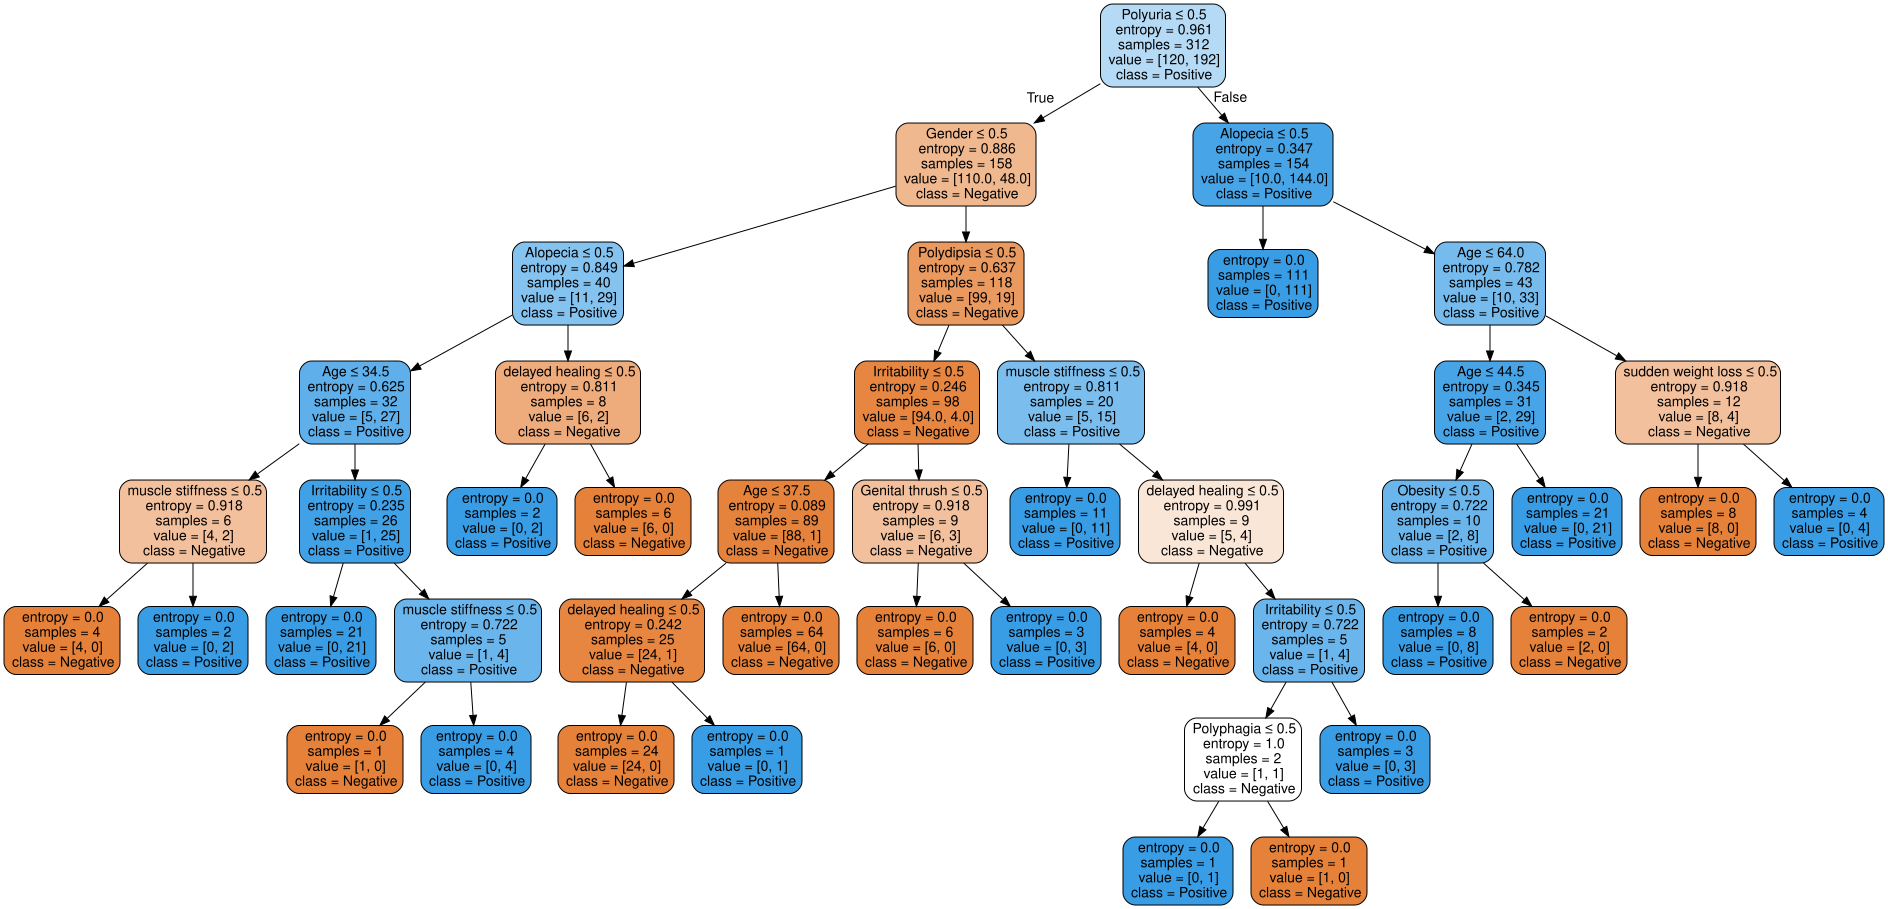



==================== TỶ LỆ TRAIN: 80% - TEST: 20% ====================
Confusion Matrix (Ma trận nhầm lẫn):
[[40  0]
 [ 1 63]]

Classification Report (Báo cáo chi tiết):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104

-> Hình ảnh cây quyết định cho tỷ lệ 80/20:


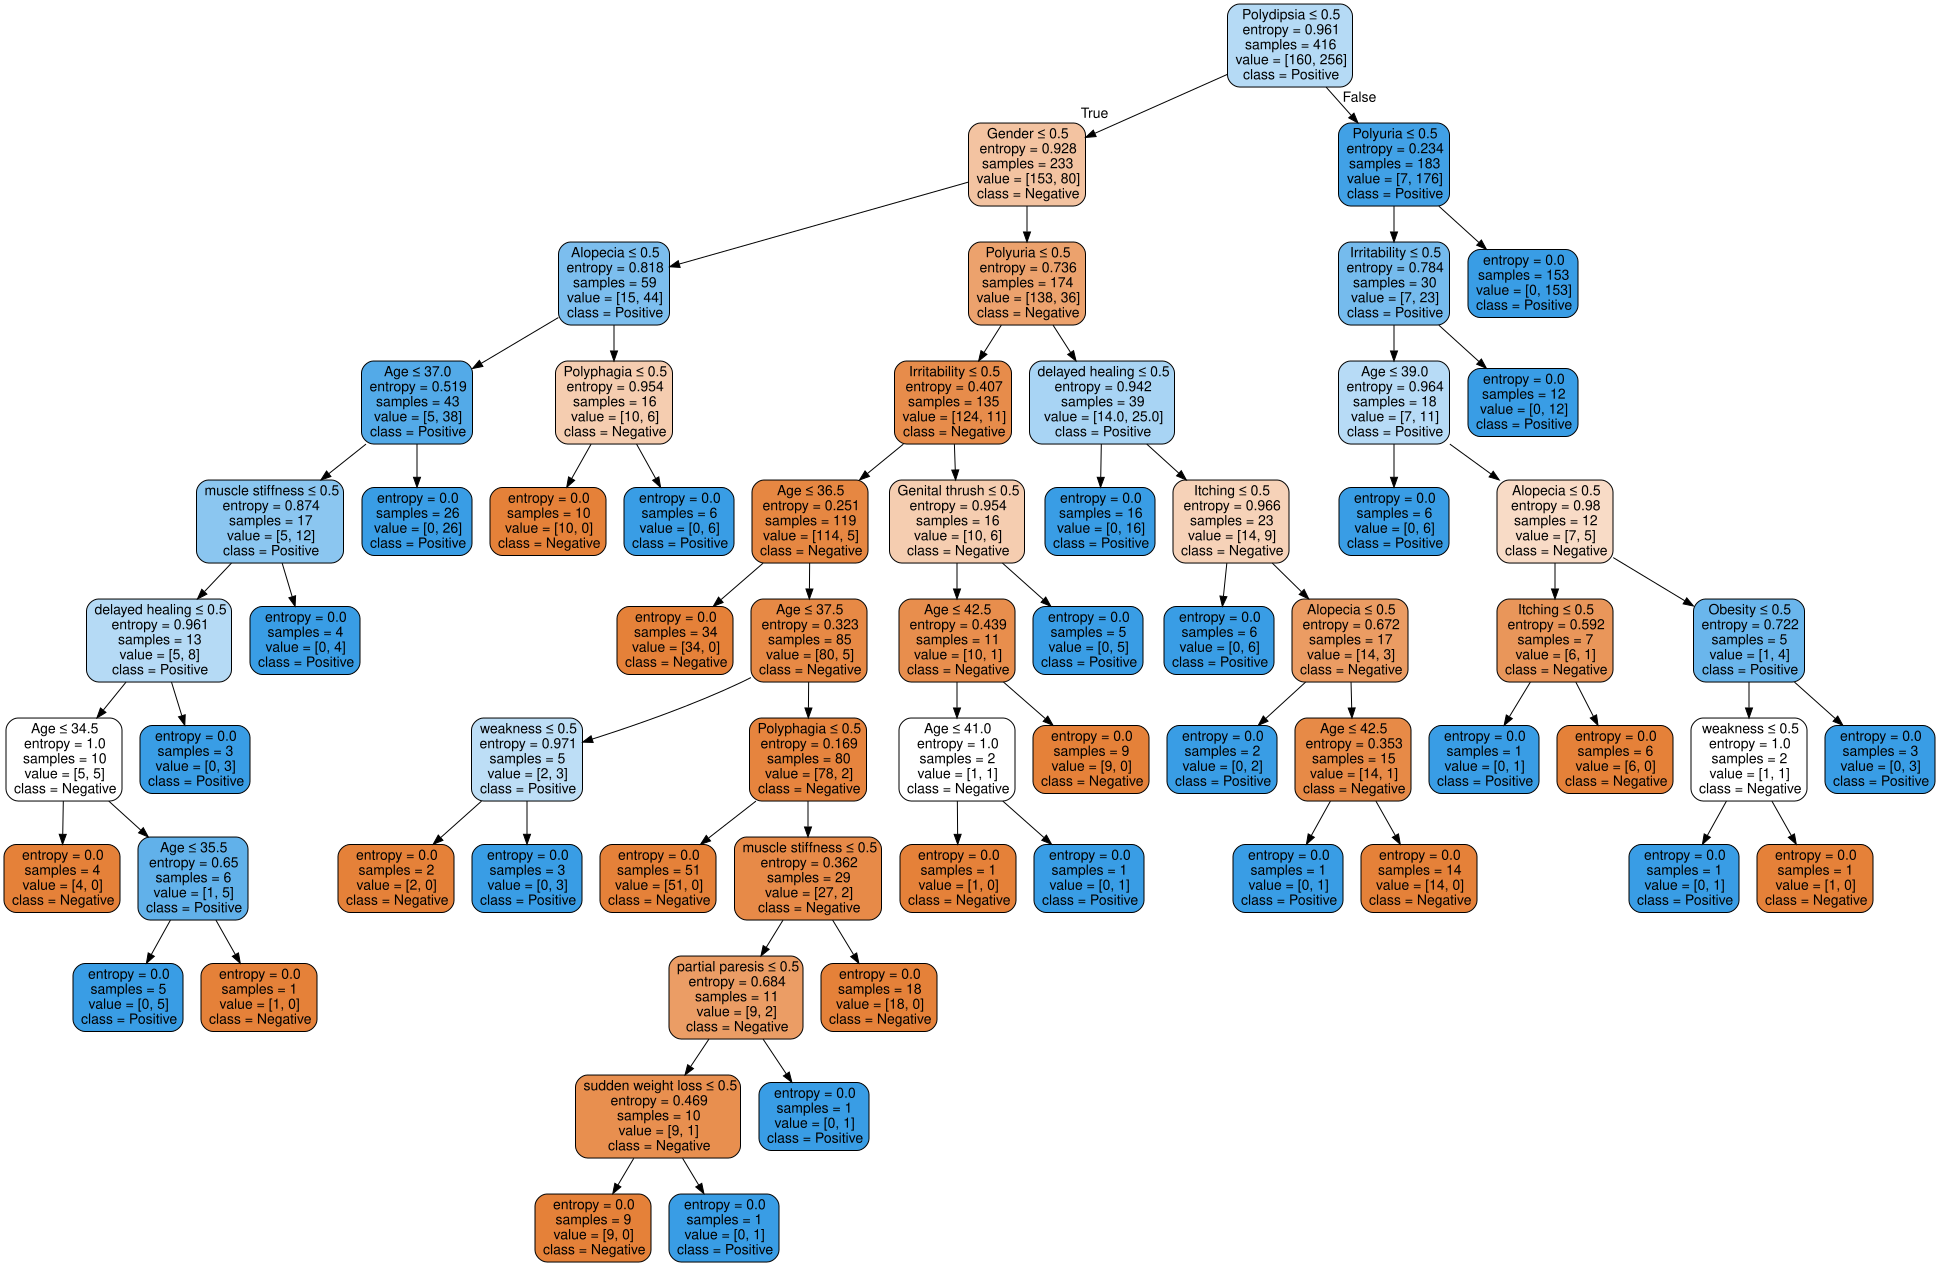



==================== TỶ LỆ TRAIN: 90% - TEST: 10% ====================
Confusion Matrix (Ma trận nhầm lẫn):
[[20  0]
 [ 1 31]]

Classification Report (Báo cáo chi tiết):
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.97      0.98        32

    accuracy                           0.98        52
   macro avg       0.98      0.98      0.98        52
weighted avg       0.98      0.98      0.98        52

-> Hình ảnh cây quyết định cho tỷ lệ 90/10:


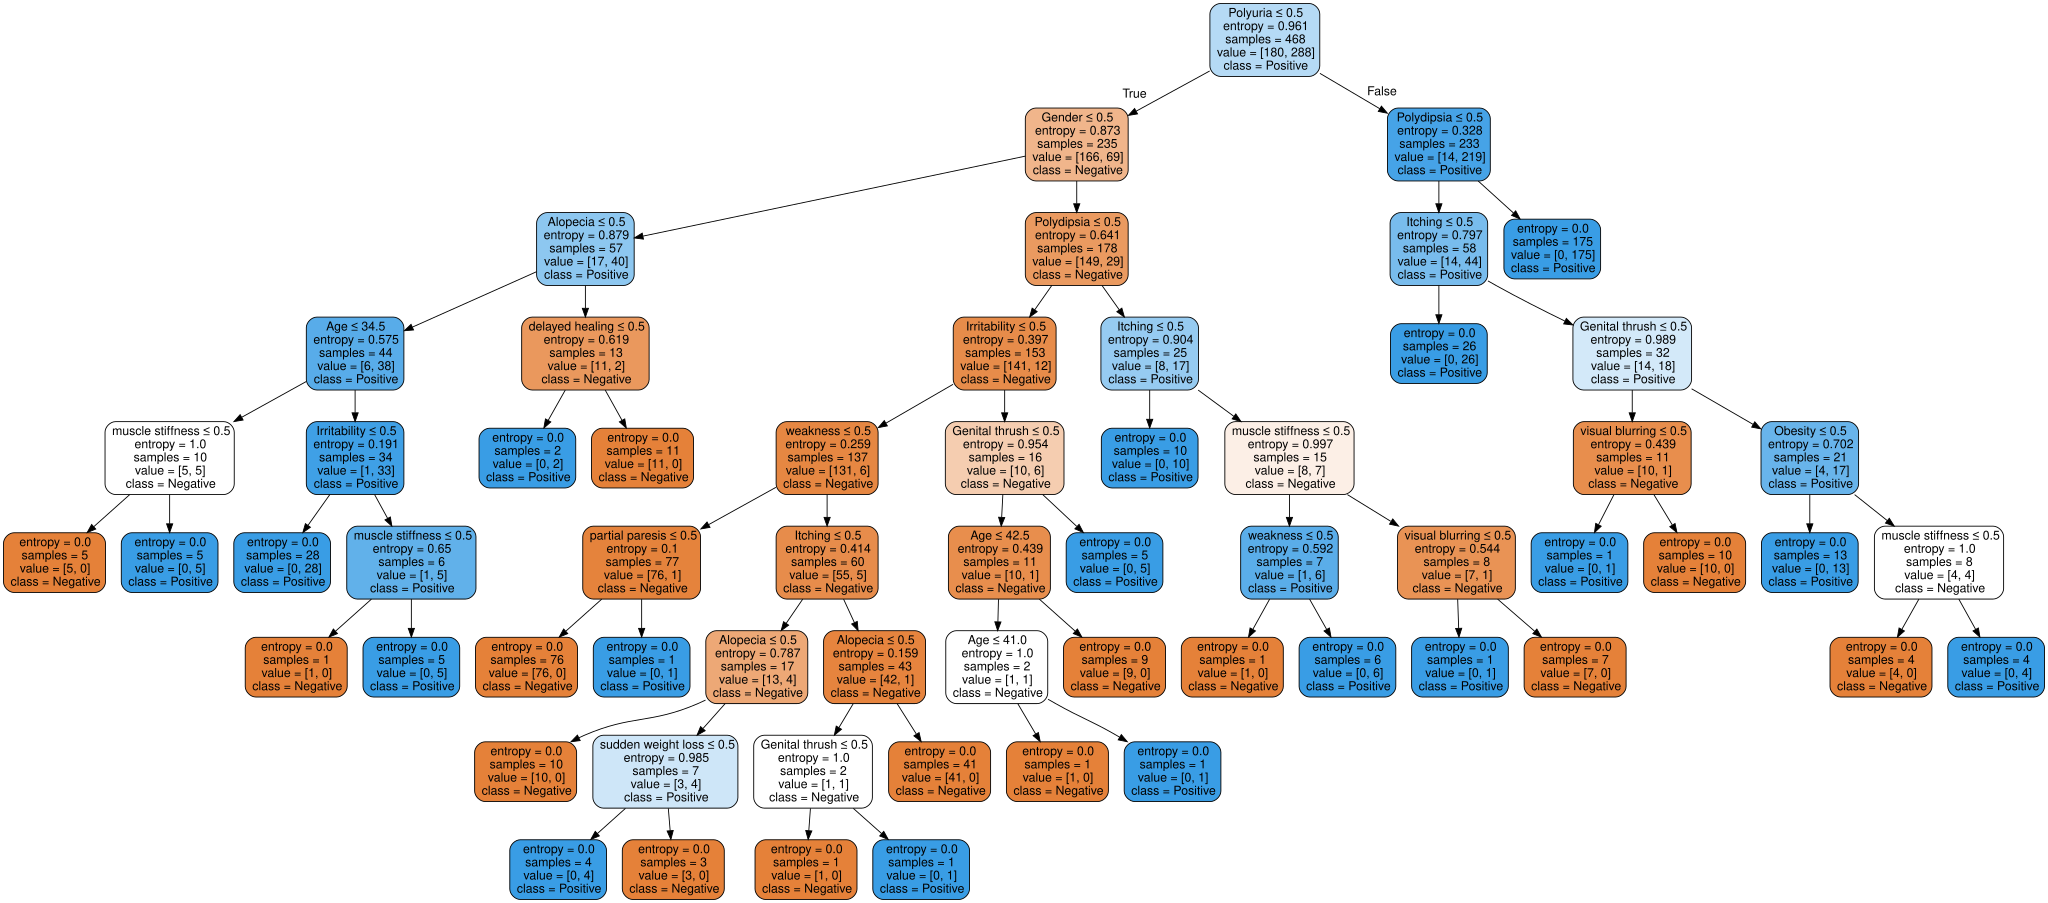

In [3]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix
import graphviz
from IPython.display import display # Thư viện để hiển thị ảnh trong vòng lặp

# Định nghĩa lại tỷ lệ để chạy vòng lặp
ratios = [0.4, 0.6, 0.8, 0.9]

print("=== BƯỚC 2: HUẤN LUYỆN VÀ ĐÁNH GIÁ CÂY QUYẾT ĐỊNH (ENTROPY) ===")

for train_size in ratios:
    # 1. Chia dữ liệu (Lặp lại thao tác chuẩn bị dữ liệu)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, stratify=y, random_state=42
    )

    # 2. Xây dựng cây (Mục 2.2)
    # Lưu ý: Đề bài yêu cầu dùng "Information Gain" -> criterion='entropy'
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)

    # 3. Dự đoán trên tập Test
    y_pred = clf.predict(X_test)

    # 4. In kết quả đánh giá (Mục 2.3)
    print(f"\n\n{'='*20} TỶ LỆ TRAIN: {round(train_size*100)}% - TEST: {round((1-train_size)*100)}% {'='*20}")
    print("Confusion Matrix (Ma trận nhầm lẫn):")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report (Báo cáo chi tiết):")
    # In ra độ chính xác, precision, recall...
    print(classification_report(y_test, y_pred))

    # 5. Vẽ cây (Visualize)
    print(f"-> Hình ảnh cây quyết định cho tỷ lệ {round(train_size*100)}/{round((1-train_size)*100)}:")
    dot_data = export_graphviz(clf, out_file=None,
                               feature_names=X.columns,
                               class_names=['Negative', 'Positive'], # 0: Không bệnh, 1: Có bệnh
                               filled=True, rounded=True,
                               special_characters=True)
    graph = graphviz.Source(dot_data)
    display(graph) # Hiển thị cây ngay trong Colab

#3. Khảo sát ảnh hưởng của độ sâu cây

=== BẮT ĐẦU KHẢO SÁT VÀ VẼ CÂY TRỰC TIẾP ===


### 🌳 Cây quyết định với độ sâu Max Depth = 2

-> Độ chính xác (Accuracy): 0.8462


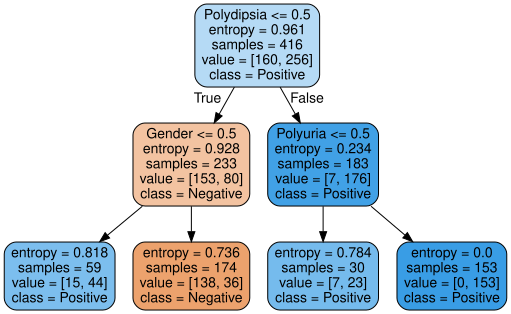

--------------------------------------------------------------------------------


### 🌳 Cây quyết định với độ sâu Max Depth = 3

-> Độ chính xác (Accuracy): 0.9423


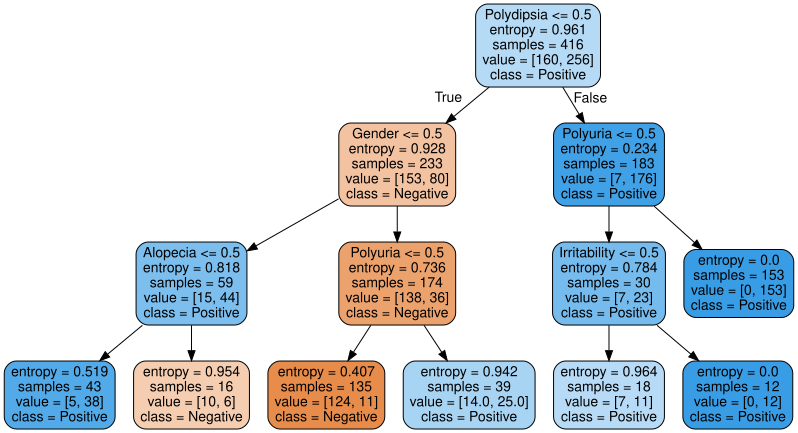

--------------------------------------------------------------------------------


### 🌳 Cây quyết định với độ sâu Max Depth = 4

-> Độ chính xác (Accuracy): 0.9038


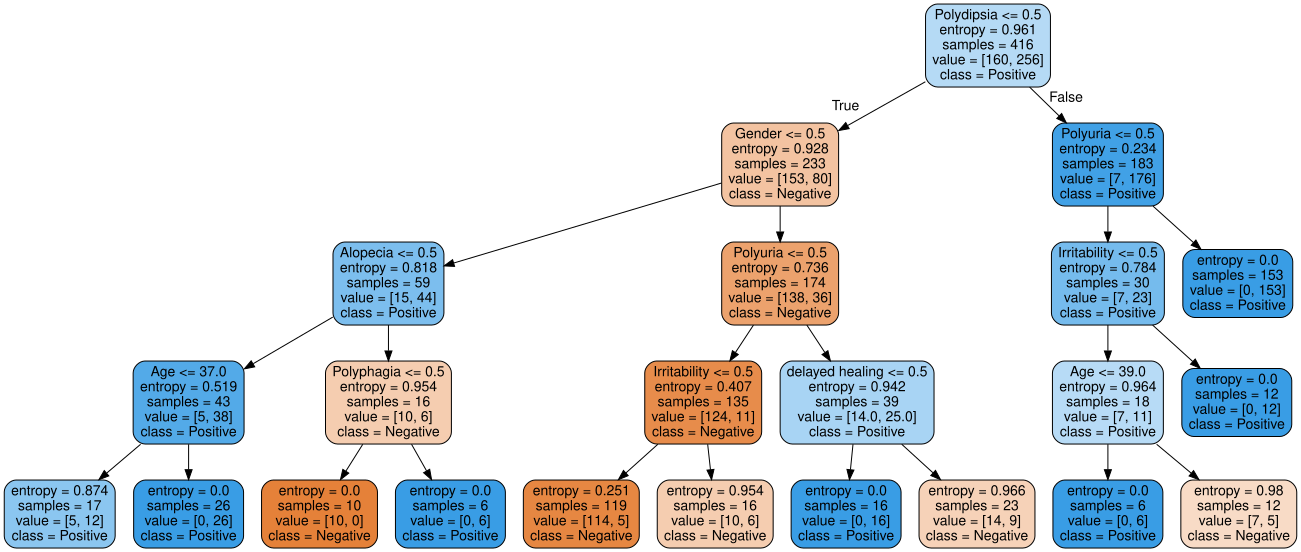

--------------------------------------------------------------------------------


### 🌳 Cây quyết định với độ sâu Max Depth = 5

-> Độ chính xác (Accuracy): 0.9423


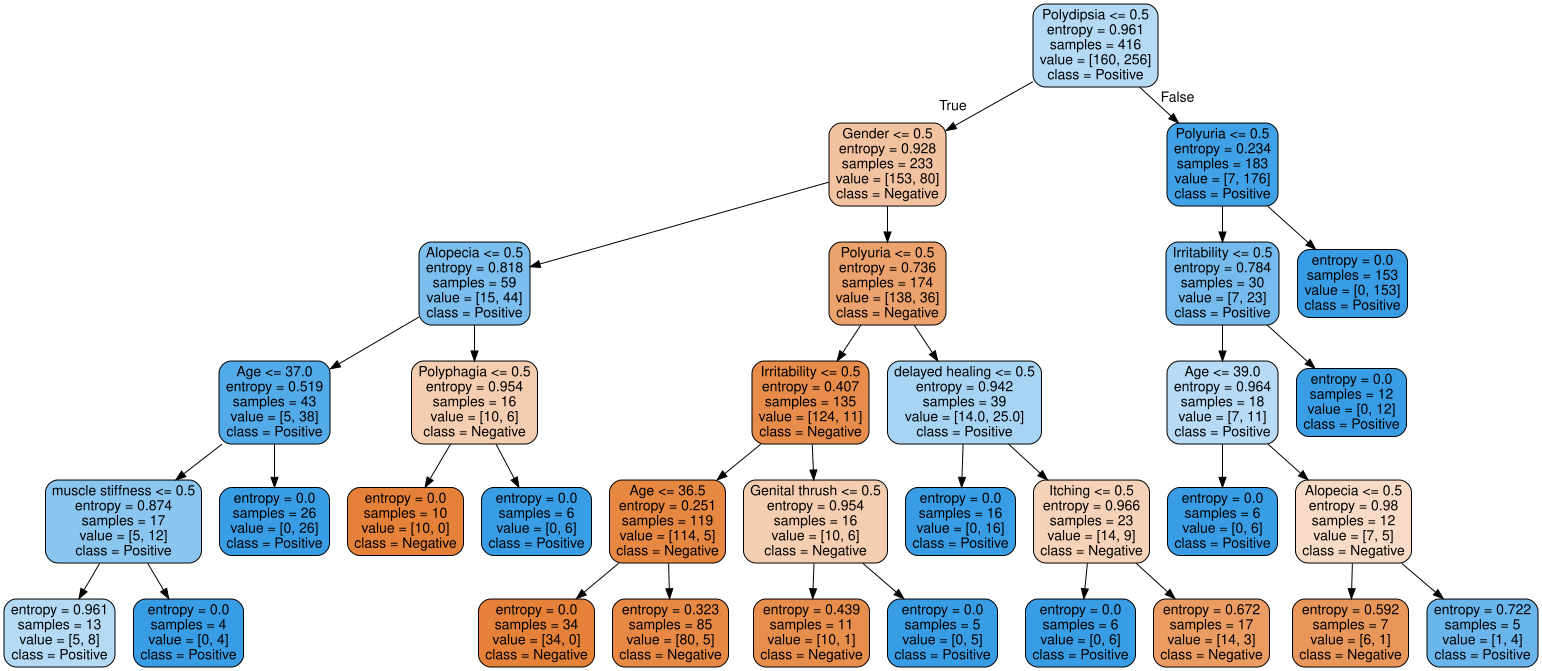

--------------------------------------------------------------------------------


### 🌳 Cây quyết định với độ sâu Max Depth = 6

-> Độ chính xác (Accuracy): 0.9327


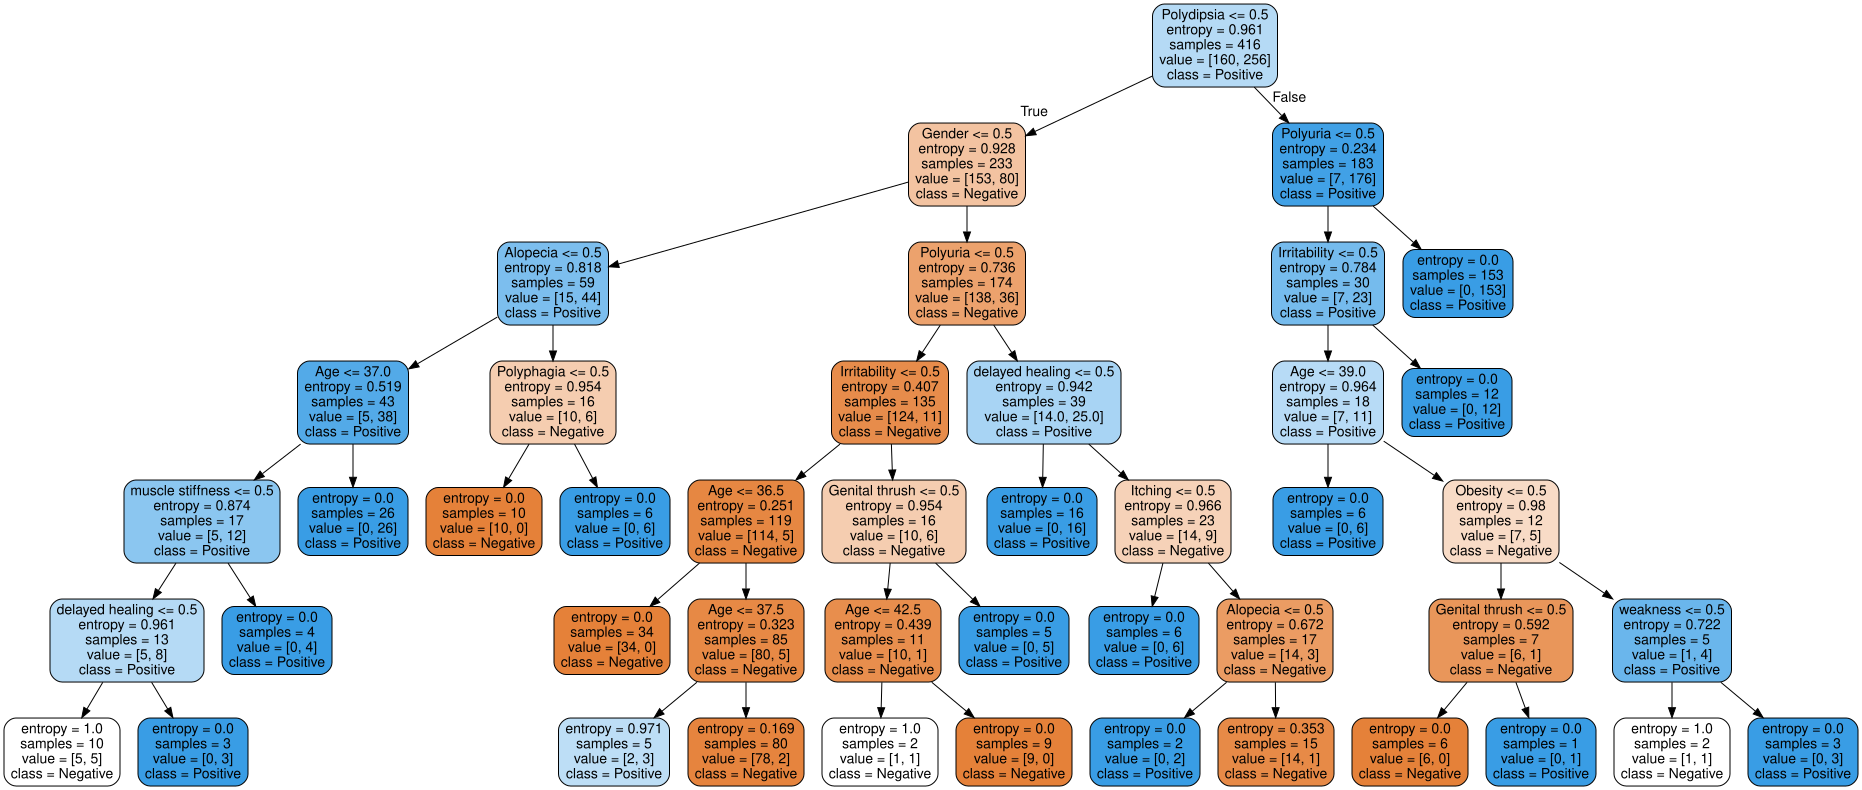

--------------------------------------------------------------------------------


### 🌳 Cây quyết định với độ sâu Max Depth = 7

-> Độ chính xác (Accuracy): 0.9808


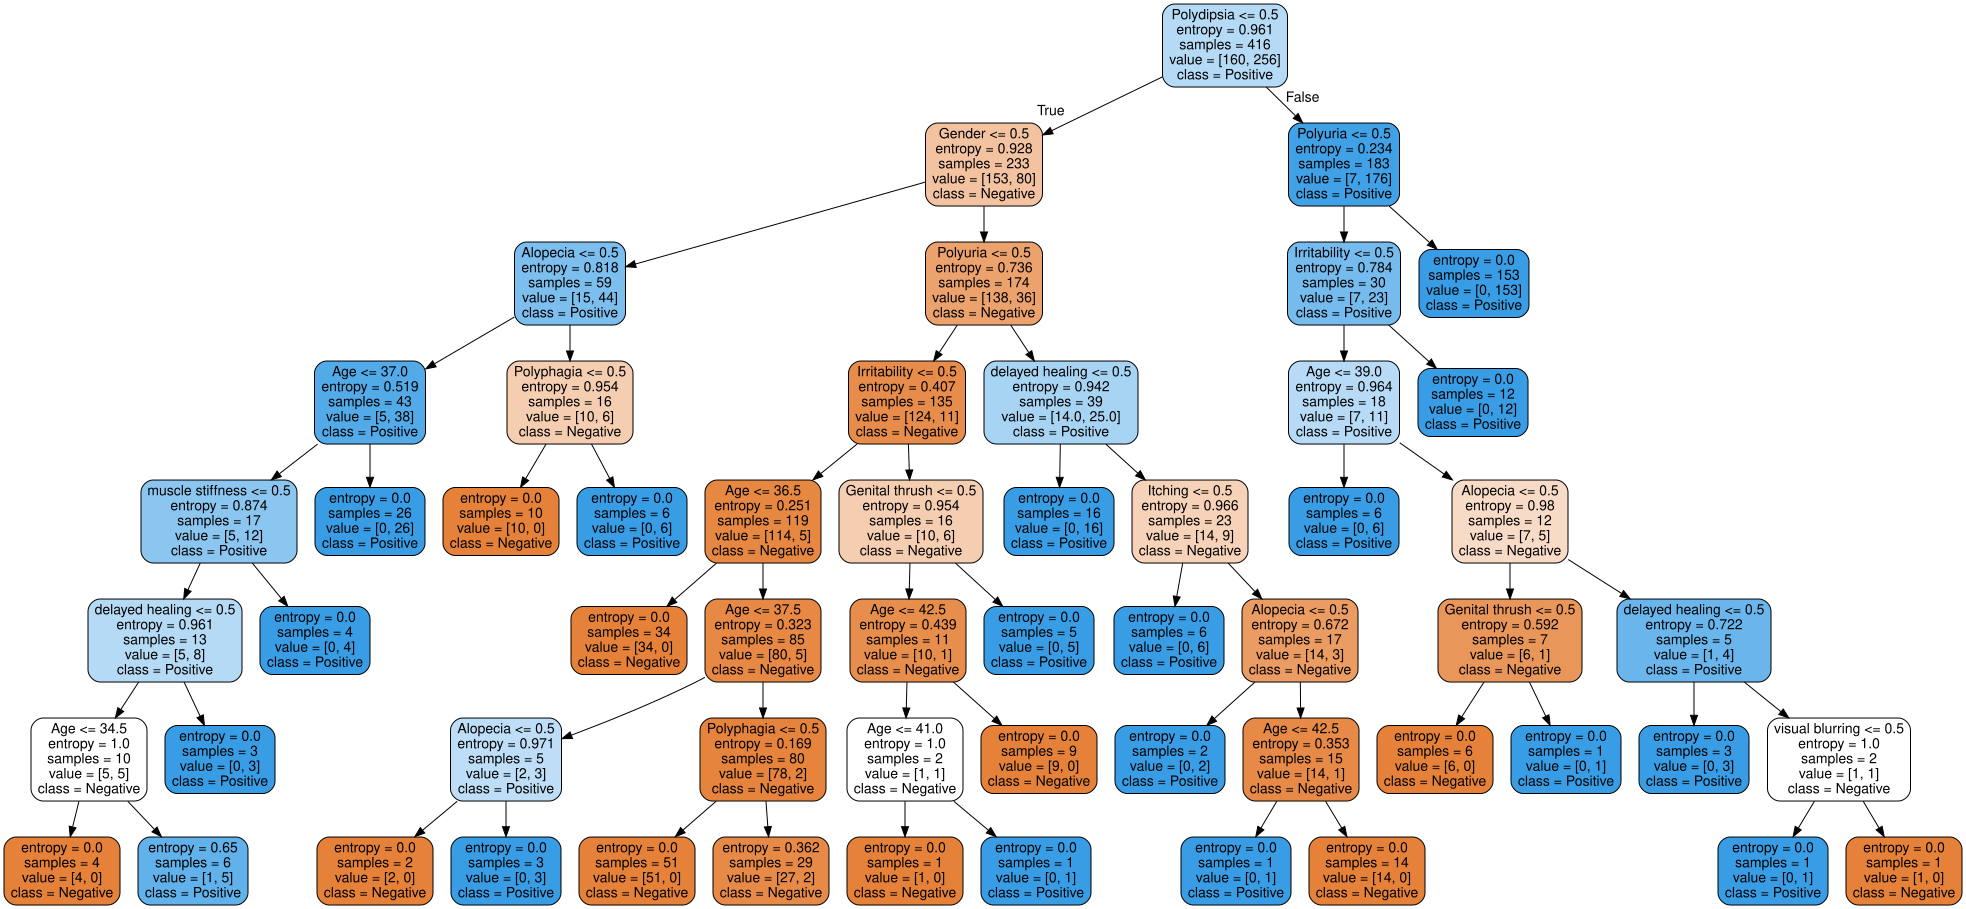

--------------------------------------------------------------------------------


### 🌳 Cây quyết định với độ sâu Max Depth = None (Không giới hạn)

-> Độ chính xác (Accuracy): 0.9904


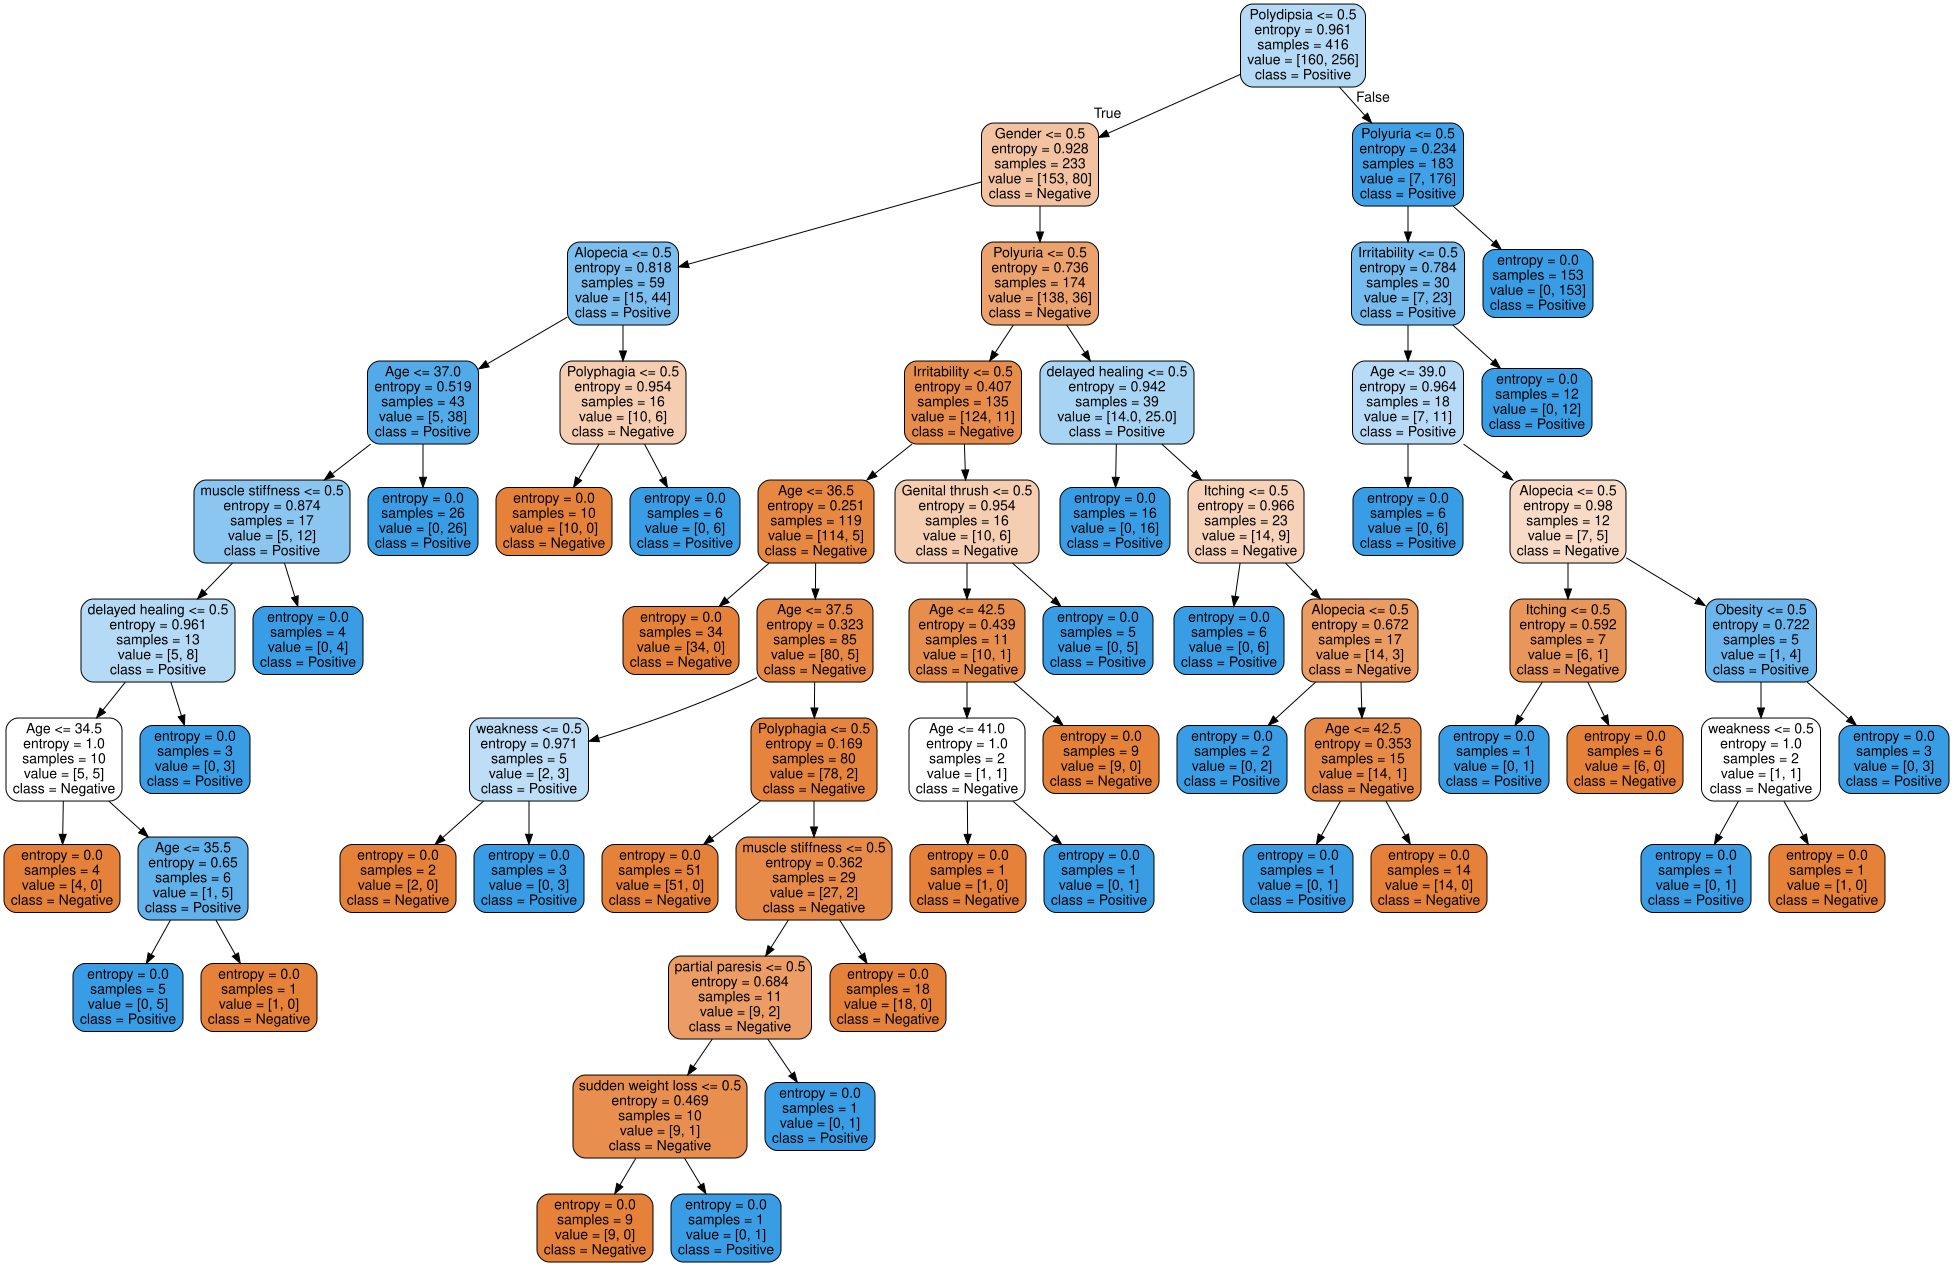

--------------------------------------------------------------------------------


### 📈 Biểu đồ so sánh độ chính xác theo độ sâu

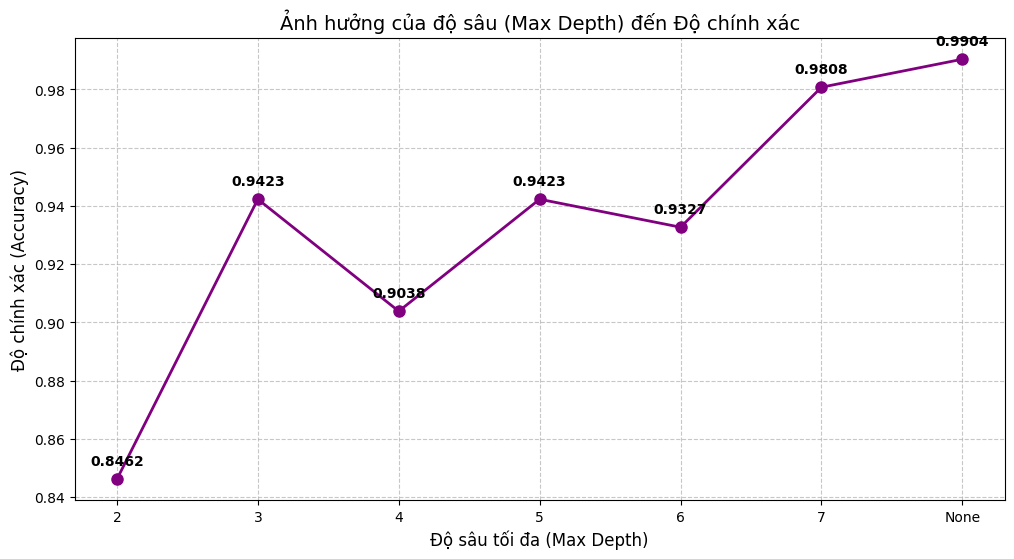


=== BẢNG TỔNG HỢP KẾT QUẢ ===
Max Depth  | Accuracy  
-------------------------
2          | 0.8462
3          | 0.9423
4          | 0.9038
5          | 0.9423
6          | 0.9327
7          | 0.9808
None       | 0.9904


In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import graphviz
from IPython.display import display, Markdown # Thư viện để hiển thị ảnh và chữ đẹp

# --- 1. CHUẨN BỊ DỮ LIỆU (Tỷ lệ 80/20) ---
# (Giả sử bạn đã có X, y từ các bước trước. Nếu chưa thì chạy lại đoạn load dữ liệu nhé)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=42
)

depths = [2, 3, 4, 5, 6, 7, None]
results = []

print("=== BẮT ĐẦU KHẢO SÁT VÀ VẼ CÂY TRỰC TIẾP ===")

# --- 2. VÒNG LẶP HUẤN LUYỆN & VẼ CÂY ---
for d in depths:
    # Huấn luyện
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    # Tính Accuracy
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append(acc)

    # Hiển thị tiêu đề cho từng cây
    depth_name = str(d) if d is not None else "None (Không giới hạn)"
    display(Markdown(f"### 🌳 Cây quyết định với độ sâu Max Depth = {depth_name}"))
    print(f"-> Độ chính xác (Accuracy): {acc:.4f}")

    # Vẽ cây trực tiếp
    dot_data = export_graphviz(clf, out_file=None,
                               feature_names=X.columns,
                               class_names=['Negative', 'Positive'],
                               filled=True, rounded=True)

    # Lệnh này sẽ show hình ngay lập tức bên dưới dòng print
    graph = graphviz.Source(dot_data)
    display(graph)

    print("-" * 80) # Dòng kẻ ngăn cách cho dễ nhìn

# --- 3. VẼ BIỂU ĐỒ SO SÁNH (LINE CHART) ---
display(Markdown("### 📈 Biểu đồ so sánh độ chính xác theo độ sâu"))

plt.figure(figsize=(12, 6))
labels = [str(d) if d is not None else "None" for d in depths]
plt.plot(labels, results, marker='o', color='purple', linestyle='-', linewidth=2, markersize=8)

# Trang trí biểu đồ
plt.title('Ảnh hưởng của độ sâu (Max Depth) đến Độ chính xác', fontsize=14)
plt.xlabel('Độ sâu tối đa (Max Depth)', fontsize=12)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Hiện số liệu lên từng điểm
for i, txt in enumerate(results):
    plt.annotate(f"{txt:.4f}", (labels[i], results[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.show()

# --- 4. IN BẢNG TỔNG HỢP ---
print("\n=== BẢNG TỔNG HỢP KẾT QUẢ ===")
print(f"{'Max Depth':<10} | {'Accuracy':<10}")
print("-" * 25)
for i, d in enumerate(depths):
    lbl = str(d) if d is not None else "None"
    print(f"{lbl:<10} | {results[i]:.4f}")